# Classification and Cross-Platform Validation Using DNA Methylation Data

## Coursework Spec

Deal with high dimensional epigenomic data using feature selection, dimensionality reduction and data visualisation (PCA, t-SNE, UMAP)

Dataset contains DNA methylation beta values (0-1), samples from 450k and epic, and 8 subtype labels

- Primary aim: prepare and curate the dataset
- Retrieve data from GEO
- Clear conceptual understanding of key papers to make informed preprocessing and feature selection decisions
- Data collection, insection, filtering, cleaning and transformation
- Careful feature selection, preprocessing and dimensionality reduction


## Recipes from Paper

1. Acquire [GSE130051](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE130051) data from GEO [GEOparser?]
    - Contains IDAT and miniml files
2. Generate and clean EPIC Beta Values using SeSAMe (R) or Pylluminator or Methylprep
    - Probe masking (XY chromomsomes, low quality)
    - Channel inference (fix manifest file errors)
    - Dye Bias correction 
    - P-value masking (pOOBAH)
    - Background correction (NOOB)
    - Batch effect correction (ComBat) [optional]
    - Use CNV analysis for Gain/Loss plots?
3. Do standard data checks (missing target, duplicates)
4. Split into train/test to avoid data leakage (model seeing std of full/test data)
5. Rank probes on standard deviation, select top 25000?
6. Filter on correlation (> 0.4?)
7. Inner join on HM450 and EPIC
8. Impute missing values
    - Use directly matching probes for 1:1 replacement?
    - Use KNN as a baseline
    - Use IterativeImputer + RandomForestRegressor (aka MissForest, a type of MICE - Multivariate Imputation by Chained Equations)
9. Perform dimensionality reduction
    - PCA to visualise in 3D
    - t-SNE to visualise in 2D
    - NMF to create metagenes
10. Save metagenes as the final dataset


## Data Acquisition



In [2]:
# Import libraries

import GEOparse
from pathlib import Path
import warnings
import subprocess
import gzip
import gc

import pandas as pd
import polars as pl

from pylluminator.annotations import Annotations, ArrayType, GenomeVersion
from pylluminator.samples import Samples, read_samples
from pylluminator.visualizations import betas_density, betas_dendrogram, betas_2D, nb_probes_per_chr_and_type_hist
from pylluminator.utils import set_logger, download_from_geo

In [2]:
# Read metadata from parquet file
df_meta = pd.read_parquet("./data/GSE130051_metadata.parquet")

# Review the metadata
df_meta

,gsm,cohort,tissue,subgroup,subtype,title,platform
0,GSM3876338,GSE93646,Medulloblastoma,MB_G4,8,6026818126_R01C01,GPL13534
1,GSM3876339,GSE93646,Medulloblastoma,MB_G3,2,6026818126_R04C01,GPL13534
2,GSM3876340,GSE93646,Medulloblastoma,MB_G3,4,6026818136_R01C02,GPL13534
3,GSM3876341,GSE93646,Medulloblastoma,MB_G3,2,6164655140_R01C01,GPL13534
4,GSM3876342,GSE93646,Medulloblastoma,MB_G3,2,6164655140_R03C01,GPL13534
...,...,...,...,...,...,...,...
1496,GSM3877852,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G4,6,200876170073_R07C01,GPL21145
1497,GSM3877853,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G4,8,200882160027_R04C01,GPL21145
1498,GSM3877854,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G3,7,200925700136_R04C01,GPL21145
1499,GSM3877855,Previously unpublished - sample from St. Jude ...,Medulloblastoma,MB_G4,7,9444374158_R02C01,GPL13534


## Data Preprocessing

### Read Samples

Generate a sample sheet, dropping probes with missing design type or channel, creating a manifest for EPIC, merging the manifest to the sample dataset (losing 4.18% of probes in the process) and masking probes. Final output: 110 samples.

In [3]:
'''epic_dir = 'data/EPIC'
samples = read_samples(epic_dir)
samples.save('data/EPIC/raw_samples')'''

samples = Samples.load('data/EPIC/raw_samples')

INFO:pylluminator.utils:Loading <class 'pylluminator.samples.Samples'> object from data/EPIC/raw_samples


In [4]:
samples.sample_sheet

,sample_id,sample_name,sentrix_id,sentrix_position
0,GSM3877770,GSM3877770,200603290061,R05C01
1,GSM3877804,GSM3877804,200654430024,R08C01
2,GSM3877810,GSM3877810,200661820053,R04C01
3,GSM3877748,GSM3877748,200598360029,R03C01
4,GSM3877848,GSM3877848,200788260028,R05C01
...,...,...,...,...
105,GSM3877806,GSM3877806,200654520054,R05C01
106,GSM3877774,GSM3877774,200603290063,R01C01
107,GSM3877786,GSM3877786,200627670054,R01C01
108,GSM3877779,GSM3877779,200627670018,R02C01


In [5]:
samples.get_signal_df()['GSM3877770']

signal_channel                           G                R         
methylation_state                        M        U       M        U
type channel probe_type probe_id                                    
I    G       cg         cg00000769   503.0   8604.0   725.0   1828.0
                        cg00000957  8568.0   2233.0  1691.0   2360.0
                        cg00002033  2813.0   6011.0   626.0    759.0
                        cg00002934   390.0  10423.0   546.0   1713.0
                        cg00003287  8899.0   3299.0   896.0    589.0
...                                    ...      ...     ...      ...
II   nan     snp        rs877309     521.0      NaN     NaN  11990.0
                        rs9363764   4735.0      NaN     NaN   6354.0
                        rs939290     514.0      NaN     NaN   6354.0
                        rs966367    4499.0      NaN     NaN   5438.0
                        rs9839873   4092.0      NaN     NaN   3243.0

[866519 rows x 4 columns]

INFO:pylluminator.utils:Calculate beta values


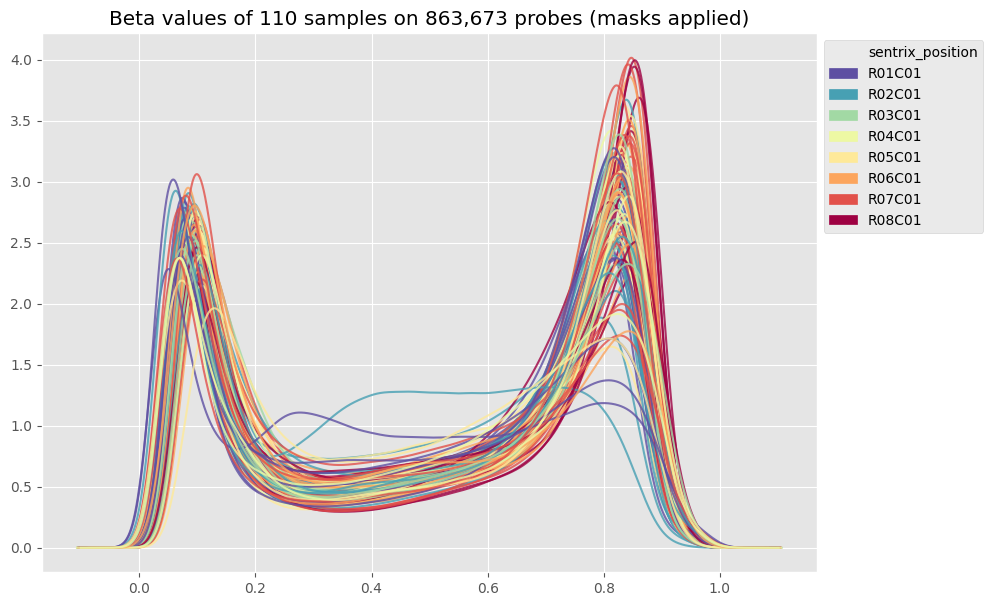

In [6]:
samples.calculate_betas(include_out_of_band=True)
betas_density(samples, color_column='sentrix_position')

### Data Cleaning

Inferring the type I channel, identifying probes with a p-value of over 0.05, applying background correction and removing the dye bias.

In [ ]:
samples.infer_type1_channel()
samples.poobah(threshold=0.05)
samples.noob_background_correction()
samples.dye_bias_correction()

INFO:pylluminator.utils:Infer type I channel..
INFO:pylluminator.utils:start pOOBAH
INFO:pylluminator.utils:NOOB background correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias correction..
INFO:pylluminator.utils:Dye bias co

### Mask Data

In [ ]:
samples.mask_xy_probes()
samples.mask_snp_probes()
samples.mask_quality_probes()

### Calculate Beta Values

In [ ]:
samples.calculate_betas()
epic_betas = samples.get_betas(apply_mask=True)

output_path = 'data/EPIC/betas.parquet'

epic_betas.to_parquet(output_path)
print(f"Workflow complete. Processed {samples.nb_samples} samples.")

INFO:pylluminator.utils:Calculate beta values


Workflow complete. Processed 110 samples.


In [4]:
output_path = 'data/EPIC/betas.parquet'

epic_betas = pd.read_parquet(output_path)
epic_betas

GSM3877742  GSM3877746  GSM3877747  \
type channel probe_type probe_id                                         
I    G       cg         cg00000769    0.036609    0.021147    0.022627   
                        cg00000957    0.803064    0.908209    0.821086   
                        cg00002033    0.915051    0.862666    0.480136   
                        cg00002934    0.025914    0.015669    0.017209   
                        cg00003287    0.898693    0.841949    0.771292   
...                                        ...         ...         ...   
II   nan     snp        rs877309           NaN         NaN         NaN   
                        rs9363764          NaN         NaN         NaN   
                        rs939290           NaN         NaN         NaN   
                        rs966367           NaN         NaN         NaN   
                        rs9839873          NaN         NaN         NaN   

                                    GSM3877748  GSM3877749  GSM3877750  \
type channel probe_type probe_id                                         
I    G       cg         cg00000769    0.020829    0.018776    0.018789   
                        cg00000957    0.817095    0.782053    0.668382   
                        cg00002033    0.920324    0.710321    0.965947   
                        cg00002934    0.017232    0.016947    0.013324   
                        cg00003287    0.712576    0.676723    0.800150   
...                                        ...         ...         ...   
II   nan     snp        rs877309           NaN         NaN         NaN   
                        rs9363764          NaN         NaN         NaN   
                        rs939290           NaN         NaN         NaN   
                        rs966367           NaN         NaN         NaN   
                        rs9839873          NaN         NaN         NaN   

                                    GSM3877751  GSM3877752  GSM3877753  \
type channel probe_type probe_id                                         
I    G       cg         cg00000769    0.033732    0.027621    0.023335   
                        cg00000957    0.699987    0.722499    0.890303   
                        cg00002033    0.914296    0.937903    0.634029   
                        cg00002934    0.021604    0.019227    0.018477   
                        cg00003287    0.603078    0.889397    0.728876   
...                                        ...         ...         ...   
II   nan     snp        rs877309           NaN         NaN         NaN   
                        rs9363764          NaN         NaN         NaN   
                        rs939290           NaN         NaN         NaN   
                        rs966367           NaN         NaN         NaN   
                        rs9839873          NaN         NaN         NaN   

                                    GSM3877754  ...  GSM3877845  GSM3877846  \
type channel probe_type probe_id                ...                           
I    G       cg         cg00000769    0.022544  ...    0.026081    0.044215   
                        cg00000957    0.664780  ...    0.609864    0.829463   
                        cg00002033    0.929655  ...    0.926266    0.657801   
                        cg00002934    0.016194  ...    0.026215    0.026439   
                        cg00003287    0.241358  ...    0.539867    0.050894   
...                                        ...  ...         ...         ...   
II   nan     snp        rs877309           NaN  ...         NaN         NaN   
                        rs9363764          NaN  ...         NaN         NaN   
                        rs939290           NaN  ...         NaN         NaN   
                        rs966367           NaN  ...         NaN         NaN   
                        rs9839873          NaN  ...         NaN         NaN   

                                    GSM3877847  GSM3877848  GSM3877849  \
type channel probe_type probe_id             

## HM450 

In [3]:
hm450_meta = df_meta[(df_meta["platform"] == "GPL13534") & (df_meta["subgroup"].notna())] 

valid_hm450_samples = set(hm450_meta["gsm"].to_list())

print(f"Targeting {len(valid_hm450_samples)} valid HM450 samples.")

Targeting 1391 valid HM450 samples.


In [3]:
# define those parameters to match your data
array_type = ArrayType.HUMAN_450K  # run ArrayType? to see available types
genome_version = GenomeVersion.HG38  # run GenomeVersion? to see available genome versions

hm450_anno = Annotations(array_type, genome_version)

hm450_anno.probe_infos
probe_infos = hm450_anno.probe_infos

probe_infos.to_parquet("data/hm450_probe_infos.parquet")

INFO:pylluminator.utils:Dropping 64 probes with missing design type or channel


In [ ]:
probe_infos = pd.read_parquet("data/hm450_probe_infos.parquet")

sex_probes = probe_infos[
    probe_infos['chromosome'].isin(["X", "Y", "chrX", "chrY"])
]['probe_id'].tolist()

masked_probes = probe_infos[
    (probe_infos['mask_info']!='') &
    (probe_infos['mask_info'].notna())
]['probe_id'].tolist()

probes_to_remove = set(sex_probes + masked_probes)

print(f"Filtering Statistics:")
print(f"- Sex Probes: {len(sex_probes)}")
print(f"- Masked Probes: {len(masked_probes)}")
print(f"- Total unique probes to remove: {len(probes_to_remove)}")

Filtering Statistics:
- Sex Probes: 14802
- Masked Probes: 0
- Total unique probes to remove: 11660


In [ ]:
schema = pl.scan_csv("data/GSE130051_beta_values.csv").collect_schema()
id_col_name = list(schema.keys())[0]

id_col_name

FileNotFoundError: No such file or directory (os error 2): data/GSE130051_beta_values.csv.gz

In [7]:
hm450_path = "data/GSE130051_beta_values.csv"
epic_path = "data/EPIC/betas.parquet"

epic_df = pl.read_parquet(epic_path)

probe_col = "probe_id" 
meta_cols = ["type", "channel", "probe_type", "address_a", "address_b", "cat"] # Exclude these

sample_cols = [c for c in epic_df.columns if c not in meta_cols and c != probe_col]

epic_df_transposed = (
    epic_df.select([probe_col] + sample_cols)
    .transpose(include_header=True, header_name="sample_id", column_names=probe_col)
)

print(f"   EPIC Transposed Shape: {epic_df_transposed.shape} (Samples x Probes)")

epic_probes_set = set(epic_df_transposed.columns)
if "sample_id" in epic_probes_set: epic_probes_set.remove("sample_id")

   EPIC Transposed Shape: (110, 866520) (Samples x Probes)


In [9]:
print("2. Parsing HM450 Header for intersection...")
with open(hm450_path, 'rt') as f:
    header_line = f.readline().strip()
    first_row = f.readline().strip()
    # Clean quotes commonly found in R CSVs
    raw_header = [x.strip('"') for x in header_line.split(',')]
    n_data_cols = len(first_row.split(','))

# Detect Shifted Header (Row Names in first column, but no header for it)
is_shifted = len(raw_header) == (n_data_cols - 1)
print(f"   Shifted Header: {is_shifted} (Header={len(raw_header)}, Data={n_data_cols})")

# Define Data Start Index
# If shifted: Data Col 0 is SampleID. Header[0] maps to Data Col 1.
probe_data_start_idx = 1 if is_shifted else 1

2. Parsing HM450 Header for intersection...
   Shifted Header: True (Header=453152, Data=453153)


In [10]:
indices_to_load = [0] 
new_column_names = ["sample_id"]
dtype_overrides = {"column_1": pl.Utf8} # Force Sample ID to String

valid_count = 0
header_probes = raw_header if is_shifted else raw_header[1:]

for i, probe in enumerate(header_probes):
    # Calculate physical column index in the CSV
    col_idx = i + probe_data_start_idx
    
    # FILTER:
    # 1. Must be 'cg' probe
    # 2. Must NOT be in exclusion list (Sex/Mask)
    # 3. MUST be present in EPIC data (The Intersection)
    if (probe.startswith("cg") and 
        probe not in probes_to_remove and 
        probe in epic_probes_set):
        
        indices_to_load.append(col_idx)
        new_column_names.append(probe)
        dtype_overrides[f"column_{col_idx+1}"] = pl.Float32 # Force 32-bit float
        valid_count += 1

print(f"   Identified {valid_count} common probes to load.")

   Identified 438998 common probes to load.


In [11]:
# Update this to your decompressed file path (much faster than .gz)

output_parquet = "data/final_merged_dataset.parquet"

chunk_size = 1000  
processed_chunks = []

with pd.read_csv(
    hm450_path,
    header=None,
    skiprows=1,
    usecols=indices_to_load,  
    chunksize=chunk_size,
    engine='c'                
) as reader:

    for i, chunk in enumerate(reader):
        chunk.columns = new_column_names

        chunk['sample_id'] = chunk['sample_id'].astype(str)
        chunk = chunk[chunk['sample_id'].isin(valid_hm450_samples)]
        
        cols_to_downcast = [c for c in chunk.columns if c != 'sample_id']
        chunk[cols_to_downcast] = chunk[cols_to_downcast].astype('float32')
        
        if not chunk.empty:
            processed_chunks.append(chunk)
            
        if i % 10 == 0:
            print(f"   Processed chunk {i}... (Total valid samples so far: {sum(len(c) for c in processed_chunks)})", flush=True)

gc.collect()

print("4. Concatenating final dataframe...", flush=True)
hm450_df = pd.concat(processed_chunks, ignore_index=True)

# Clear the chunks list to free duplicate memory
del processed_chunks
gc.collect()

print(f"   Final HM450 Shape: {hm450_df.shape}", flush=True)
print(f"   RAM Usage: {hm450_df.memory_usage(deep=True).sum() / 1e9 :.2f} GB", flush=True)

print(f"5. Saving to {output_parquet}...", flush=True)
hm450_df.to_parquet(output_parquet, compression='snappy')

: 

## References

- The international meta-analysis establishing eight consensus molecular subtypes of Group 3 and
Group 4 medulloblastoma, published in Acta Neuropathologica (2019), which provides the
reference subtype labels used in this project:
(Sharma et al., Second-generation molecular subgrouping of medulloblastoma)
https://link.springer.com/article/10.1007/s00401-019-02020-0
- A subsequent machine learning study developing a cross-platform DNA methylation classifier
capable of predicting these eight subtypes using both Illumina HumanMethylation450 (450K) and
Illumina EPIC (850K) arrays. https://arxiv.org/pdf/2510.02416?

## Appendices 

### Appendix A - Data Download

In [ ]:
# Download raw TAR file (both platforms) and transposed beta values (HM450 only) using wget in the terminal

'''wget -O data/GSE130051_RAW.tar "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE130051&format=file"
wget -O data/GSE130051_beta_values.csv.gz "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE130051&format=file&file=GSE130051%5Fbeta%5Fvalues%2Ecsv%2Egz"`'''

'wget -O data/GSE130051_RAW.tar "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE130051&format=file"\nwget -O data/GSE130051_transposed_beta_values_GSE130051.csv.gz "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE130051&format=file&file=GSE130051%5Ftransposed%5Fbeta%5Fvalues%5FGSE130051%2Ecsv%2Egz"'

In [13]:
# Download metadata from GEO

'''gse_id = "GSE130051"
dest_dir = "./data"
dest_path = Path(dest_dir)

gse = GEOparse.get_GEO(geo=gse_id, destdir=str(dest_path), silent=True)

metadata_list = []
for gsm_id, gsm in gse.gsms.items():
    meta = {"gsm": gsm_id}
    # Flatten characteristics which are often in a list
    for char in gsm.metadata.get("characteristics_ch1", []):
        if ":" in char:
            k, v = char.split(":", 1)
            meta[k.strip()] = v.strip()
    # Also get title and platform
    meta["title"] = gsm.metadata.get("title", [""])[0]
    meta["platform"] = gsm.metadata.get("platform_id", [""])[0]
    metadata_list.append(meta)

df_meta = pl.DataFrame(metadata_list)
meta_file = dest_path / f"{gse_id}_metadata.parquet"
df_meta.write_parquet(meta_file)'''

'gse_id = "GSE130051"\ndest_dir = "./data"\ndest_path = Path(dest_dir)\n\ngse = GEOparse.get_GEO(geo=gse_id, destdir=str(dest_path), silent=True)\n\nmetadata_list = []\nfor gsm_id, gsm in gse.gsms.items():\n    meta = {"gsm": gsm_id}\n    # Flatten characteristics which are often in a list\n    for char in gsm.metadata.get("characteristics_ch1", []):\n        if ":" in char:\n            k, v = char.split(":", 1)\n            meta[k.strip()] = v.strip()\n    # Also get title and platform\n    meta["title"] = gsm.metadata.get("title", [""])[0]\n    meta["platform"] = gsm.metadata.get("platform_id", [""])[0]\n    metadata_list.append(meta)\n\ndf_meta = pl.DataFrame(metadata_list)\nmeta_file = dest_path / f"{gse_id}_metadata.parquet"\ndf_meta.write_parquet(meta_file)'

In [14]:
# Extract IDAT files from the raw tar file

'''print("\nChecking for supplementary files (IDATs)...")
tar_file = dest_path / "GSE130051_RAW.tar"

# Check if IDAT files exist
if not list(dest_path.glob("**/*.idat")):
    try:
        # Extract IDAT files
        subprocess.run(["tar", "-xf", str(tar_file), "-C", str(dest_path)], check=True)
        print("Extraction complete.")
    except Exception as e:
        print(f"Extraction failed: {e}")
        print(f"Please manually extract {tar_file}")

# Decompress any .idat.gz files found
gz_files = list(dest_path.glob("**/*.idat.gz"))
if gz_files:
    print(f"Found {len(gz_files)} compressed .idat.gz files. Decompressing...")
    for gz_path in gz_files:
        try:
            # gunzip keeping original file name (stripping .gz)
            subprocess.run(["gunzip", "-k", "-f", str(gz_path)], check=True)
        except Exception as e:
            print(f"Failed to decompress {gz_path}: {e}")
    print("Decompression complete.")'''

'print("\nChecking for supplementary files (IDATs)...")\ntar_file = dest_path / "GSE130051_RAW.tar"\n\n# Check if IDAT files exist\nif not list(dest_path.glob("**/*.idat")):\n    try:\n        # Extract IDAT files\n        subprocess.run(["tar", "-xf", str(tar_file), "-C", str(dest_path)], check=True)\n        print("Extraction complete.")\n    except Exception as e:\n        print(f"Extraction failed: {e}")\n        print(f"Please manually extract {tar_file}")\n\n# Decompress any .idat.gz files found\ngz_files = list(dest_path.glob("**/*.idat.gz"))\nif gz_files:\n    print(f"Found {len(gz_files)} compressed .idat.gz files. Decompressing...")\n    for gz_path in gz_files:\n        try:\n            # gunzip keeping original file name (stripping .gz)\n            subprocess.run(["gunzip", "-k", "-f", str(gz_path)], check=True)\n        except Exception as e:\n            print(f"Failed to decompress {gz_path}: {e}")\n    print("Decompression complete.")'

In [15]:
# Create lists of files for each platform

'''# 1. Filter the metadata for each platform
# GPL21145 = EPIC, GPL13534 = HM450
epic_df = df_meta.filter(pl.col("platform") == "GPL21145")
hm450_df = df_meta.filter(pl.col("platform") == "GPL13534")

# 2. Function to construct filenames: {gsm}_{title}_{Color}.idat
def get_filenames(df):
    files = []
    # Iterate through rows and build both Red and Grn filenames
    for row in df.iter_rows(named=True):
        base_name = f"{row['gsm']}_{row['title']}"
        files.append(f"{base_name}_Grn.idat")
        files.append(f"{base_name}_Red.idat")
    return files

# 3. Write the lists to text files
with open("epic_files.txt", "w") as f:
    f.write("\n".join(get_filenames(epic_df)))

with open("hm450_files.txt", "w") as f:
    f.write("\n".join(get_filenames(hm450_df)))

print(f"Created lists: {len(epic_df)*2} EPIC files and {len(hm450_df)*2} HM450 files.")'''

'# 1. Filter the metadata for each platform\n# GPL21145 = EPIC, GPL13534 = HM450\nepic_df = df_meta.filter(pl.col("platform") == "GPL21145")\nhm450_df = df_meta.filter(pl.col("platform") == "GPL13534")\n\n# 2. Function to construct filenames: {gsm}_{title}_{Color}.idat\ndef get_filenames(df):\n    files = []\n    # Iterate through rows and build both Red and Grn filenames\n    for row in df.iter_rows(named=True):\n        base_name = f"{row[\'gsm\']}_{row[\'title\']}"\n        files.append(f"{base_name}_Grn.idat")\n        files.append(f"{base_name}_Red.idat")\n    return files\n\n# 3. Write the lists to text files\nwith open("epic_files.txt", "w") as f:\n    f.write("\n".join(get_filenames(epic_df)))\n\nwith open("hm450_files.txt", "w") as f:\n    f.write("\n".join(get_filenames(hm450_df)))\n\nprint(f"Created lists: {len(epic_df)*2} EPIC files and {len(hm450_df)*2} HM450 files.")'

In [16]:
# Move files to appropriate folders in the terminal

'''# 1. Create the destination folders`
mkdir -p data/EPIC data/HM450

# 2. Move the EPIC files
# This reads the filenames from the text file and moves them from data/ into data/EPIC/
cat epic_files.txt | xargs -I {} mv data/{} data/EPIC/

# 3. Move the HM450 files
cat hm450_files.txt | xargs -I {} mv data/{} data/HM450/'''

'# 1. Create the destination folders`\nmkdir -p data/EPIC data/HM450\n\n# 2. Move the EPIC files\n# This reads the filenames from the text file and moves them from data/ into data/EPIC/\ncat epic_files.txt | xargs -I {} mv data/{} data/EPIC/\n\n# 3. Move the HM450 files\ncat hm450_files.txt | xargs -I {} mv data/{} data/HM450/'

## Appendix B - Data Masking